# TP_S2 — Ontologies & Knowledge Graphs
## IA symbolique appliquée à la cybersécurité

**Cours IA & Cybersécurité — Master 1 Ingénierie Aéronautique & Spatiale**

---

### Contexte

Dans le **TP_S1**, vous avez utilisé des règles SI→ALORS pour détecter des intrusions.  
Ces règles fonctionnent bien, mais elles traitent chaque événement **isolément**.

Un attaquant réel ne fait pas une seule action — il enchaîne des techniques :  
reconnaissance → intrusion → élévation de privilèges → exfiltration.

**Pour détecter une campagne d'attaque complète, il faut relier les événements entre eux.**  
C'est le rôle des **ontologies et des knowledge graphs**.

---

### Ce que vous allez faire

| Partie | Concept | Objectif |
|--------|---------|---------|
| 1 | **Triplets & graphe** | Construire un knowledge graph d'attaque |
| 2 | **Requêtes sur le graphe** | Trouver des chemins d'attaque |
| 3 | **MITRE ATT&CK** | Explorer un vrai knowledge graph cyber |

---

> 💡 **Rappel** : un knowledge graph est un ensemble de triplets  
> `[ Sujet ] ── relation ──▶ [ Objet ]`  
> Ex : `APT28 ── utilise ──▶ Spear_Phishing`


## Imports

Exécutez cette cellule en premier.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("✓ networkx", nx.__version__)
print("✓ matplotlib chargé")

---
## Partie 1 — Construire un knowledge graph d'attaque

### 1.1 — Les triplets

Un knowledge graph est une collection de **triplets** :

```
(sujet, relation, objet)
```

En cybersécurité, on peut représenter :
- Qui attaque qui
- Quelle technique est utilisée
- Quelle vulnérabilité est exploitée
- Quel système est ciblé

Voici les triplets décrivant une campagne d'attaque réelle (APT28 / opération fictive) :

| Sujet | Relation | Objet |
|-------|---------|-------|
| APT28 | utilise | Spear_Phishing |
| APT28 | cible | Ministere_Defense |
| Spear_Phishing | exploite | CVE_2024_1234 |
| CVE_2024_1234 | affecte | Outlook_365 |
| Spear_Phishing | installe | Malware_X |
| Malware_X | permet | Exfiltration_Donnees |
| Malware_X | permet | Lateral_Movement |
| Lateral_Movement | compromet | Serveur_AD |
| Serveur_AD | contient | Credentials_Admins |


### 1.2 — Créer le graphe avec networkx

In [ ]:
# Un graphe orienté = les relations ont une direction
# APT28 ──utilise──▶ Spear_Phishing  (et pas l'inverse)
G = nx.DiGraph()

# Liste des triplets : (sujet, objet, relation)
triplets = [
    ("APT28",           "Spear_Phishing",       "utilise"),
    ("APT28",           "Ministere_Defense",     "cible"),
    ("Spear_Phishing",  "CVE_2024_1234",         "exploite"),
    ("CVE_2024_1234",   "Outlook_365",           "affecte"),
    ("Spear_Phishing",  "Malware_X",             "installe"),
    ("Malware_X",       "Exfiltration_Donnees",  "permet"),
    ("Malware_X",       "Lateral_Movement",      "permet"),
    ("Lateral_Movement","Serveur_AD",            "compromet"),
    ("Serveur_AD",      "Credentials_Admins",    "contient"),
]

# TODO : ajouter chaque triplet au graphe
# Indice : G.add_edge(sujet, objet, relation=relation)
for sujet, objet, relation in triplets:
    ???

print(f"Graphe créé : {G.number_of_nodes()} noeuds, {G.number_of_edges()} arêtes")
print(f"\nNoeuds : {list(G.nodes())}")

### 1.3 — Visualisation du graphe

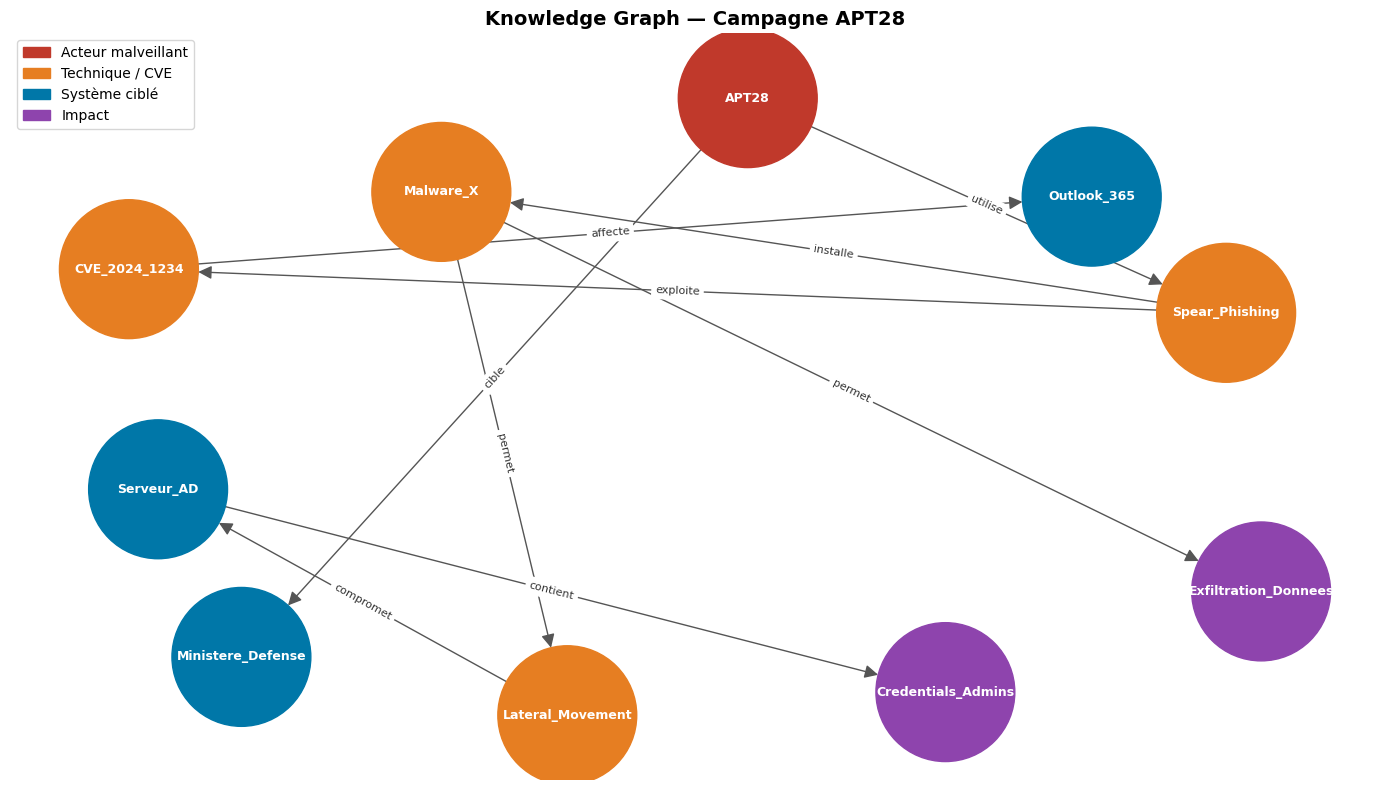

In [9]:
# Couleurs par type de noeud
couleurs_noeuds = {
    "APT28":                "#C0392B",   # rouge - acteur malveillant
    "Spear_Phishing":       "#E67E22",   # orange - technique
    "CVE_2024_1234":        "#E67E22",   # orange - technique
    "Malware_X":            "#E67E22",   # orange - technique
    "Lateral_Movement":     "#E67E22",   # orange - technique
    "Outlook_365":          "#0077A8",   # bleu - système ciblé
    "Ministere_Defense":    "#0077A8",   # bleu - système ciblé
    "Serveur_AD":           "#0077A8",   # bleu - système ciblé
    "Exfiltration_Donnees": "#8E44AD",   # violet - impact
    "Credentials_Admins":   "#8E44AD",   # violet - impact
}

node_colors = [couleurs_noeuds.get(n, "#95A5A6") for n in G.nodes()]

plt.figure(figsize=(14, 8))

# TODO : calculer la disposition des noeuds avec spring_layout
# Indice : nx.spring_layout(G, seed=42, k=2.5)
pos = ???

# TODO : dessiner le graphe
# Indice : nx.draw_networkx(G, pos, ...)
# Paramètres suggérés : node_color=node_colors, node_size=2000,
#                       font_size=9, font_color="white", font_weight="bold",
#                       arrows=True, arrowsize=20, edge_color="#555555"
nx.draw_networkx(
    G, pos,
    node_color=???,
    node_size=???,
    font_size=???,
    font_color=???,
    font_weight=???,
    arrows=???,
    arrowsize=???,
    edge_color=???,
)

# Étiquettes des relations sur les arêtes
edge_labels = nx.get_edge_attributes(G, 'relation')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                              font_size=8, font_color="#333333")

# Légende
patches = [
    mpatches.Patch(color="#C0392B", label="Acteur malveillant"),
    mpatches.Patch(color="#E67E22", label="Technique / CVE"),
    mpatches.Patch(color="#0077A8", label="Système ciblé"),
    mpatches.Patch(color="#8E44AD", label="Impact"),
]
plt.legend(handles=patches, loc="upper left", fontsize=10)
plt.title("Knowledge Graph — Campagne APT28", fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

**❓ Question 1.1**  
En regardant le graphe, décrivez en 2-3 phrases le **scénario d'attaque** représenté.  
Quel est le point d'entrée ? Quel est l'impact final ?

*Votre réponse :* ___

**❓ Question 1.2**  
Pourquoi utilise-t-on un **graphe orienté** (`DiGraph`) plutôt qu'un graphe non orienté ?  
Que signifierait une arête non orientée entre `APT28` et `Spear_Phishing` ?

*Votre réponse :* ___


---
## Partie 2 — Requêtes sur le graphe

L'intérêt d'un knowledge graph, c'est de pouvoir **interroger** les relations.  
Un analyste SOC peut demander :

- *"Quelles techniques APT28 utilise-t-il ?"*
- *"Quel est le chemin d'attaque de APT28 jusqu'aux Credentials_Admins ?"*
- *"Quels systèmes sont vulnérables à CVE_2024_1234 ?"*


### 2.1 — Voisins directs d'un noeud

In [ ]:
# Quels noeuds APT28 attaque-t-il directement ?

# TODO : récupérer les successeurs directs de "APT28"
# Indice : G.successors("APT28") retourne un itérateur
successeurs_apt28 = ???

print("APT28 est directement relié à :")
for noeud in successeurs_apt28:
    # TODO : récupérer la relation entre APT28 et ce noeud
    # Indice : G["APT28"][noeud]["relation"]
    relation = ???
    print(f"  APT28 ──{relation}──▶ {noeud}")

### 2.2 — Chemin d'attaque complet

In [ ]:
# Quel est le chemin le plus court entre APT28 et Credentials_Admins ?

# TODO : trouver le chemin le plus court entre "APT28" et "Credentials_Admins"
# Indice : nx.shortest_path(G, source=???, target=???)
chemin = ???

print(f"Chemin d'attaque : APT28 → Credentials_Admins")
print(f"Longueur : {len(chemin)-1} étapes\n")

print("Étapes :")
for i in range(len(chemin) - 1):
    noeud_src = chemin[i]
    noeud_dst = chemin[i+1]
    # TODO : récupérer la relation entre noeud_src et noeud_dst
    rel = ???
    print(f"  {i+1}. {noeud_src} ──{rel}──▶ {noeud_dst}")

### 2.3 — Tous les chemins possibles

In [ ]:
# Un attaquant peut emprunter plusieurs chemins
# networkx peut les trouver tous

# TODO : trouver TOUS les chemins simples entre "APT28" et "Credentials_Admins"
# Indice : nx.all_simple_paths(G, source=???, target=???)
tous_chemins = list(???)

print(f"Nombre de chemins possibles : {len(tous_chemins)}\n")

for i, chemin in enumerate(tous_chemins):
    print(f"Chemin {i+1} ({len(chemin)-1} étapes) : {' → '.join(chemin)}")

**❓ Question 2.1**  
D'après les chemins trouvés, lequel est le plus dangereux pour le défenseur ?  
Sur quel noeud intermédiaire faudrait-il concentrer les défenses pour couper tous les chemins ?

*Votre réponse :* ___

**❓ Question 2.2**  
Comparez cette approche avec les règles SI→ALORS du TP_S1.  
Qu'est-ce qu'un knowledge graph permet de détecter que les règles simples ne peuvent pas détecter ?

*Votre réponse :* ___


---
## Partie 3 — MITRE ATT&CK comme knowledge graph

### Qu'est-ce que MITRE ATT&CK ?

MITRE ATT&CK est une base de connaissances mondiale sur les tactiques et techniques d'attaque.  
Elle est structurée exactement comme un **knowledge graph** :

```
Groupe_APT ── utilise ──▶ Technique
Technique  ── sous-technique-de ──▶ Tactique
Tactique   ── fait-partie-de ──▶ Matrice_ATT&CK
Mitigation ── mitige ──▶ Technique
```

Nous allons construire un **extrait simplifié** de MITRE ATT&CK centré sur APT28.


### 3.1 — Construction du graphe MITRE ATT&CK (extrait)

In [ ]:
G_mitre = nx.DiGraph()

# Extrait MITRE ATT&CK — APT28 (Fancy Bear)
# Source : https://attack.mitre.org/groups/G0007/
triplets_mitre = [
    # Tactiques (colonnes MITRE)
    ("Initial_Access",      "Matrice_ATT&CK",       "partie_de"),
    ("Execution",           "Matrice_ATT&CK",       "partie_de"),
    ("Persistence",         "Matrice_ATT&CK",       "partie_de"),
    ("Exfiltration",        "Matrice_ATT&CK",       "partie_de"),

    # Techniques utilisées par APT28
    ("APT28",   "T1566_Spear_Phishing",     "utilise"),
    ("APT28",   "T1059_PowerShell",         "utilise"),
    ("APT28",   "T1078_Valid_Accounts",     "utilise"),
    ("APT28",   "T1041_Exfil_C2",           "utilise"),

    # Techniques → Tactiques
    ("T1566_Spear_Phishing",    "Initial_Access",   "appartient_a"),
    ("T1059_PowerShell",        "Execution",        "appartient_a"),
    ("T1078_Valid_Accounts",    "Persistence",      "appartient_a"),
    ("T1041_Exfil_C2",          "Exfiltration",     "appartient_a"),

    # Mitigations
    ("M1049_Antivirus",         "T1566_Spear_Phishing",  "mitige"),
    ("M1032_MFA",               "T1078_Valid_Accounts",  "mitige"),
    ("M1031_Network_Intrusion", "T1041_Exfil_C2",        "mitige"),
]

# TODO : ajouter tous les triplets au graphe G_mitre
for sujet, objet, relation in triplets_mitre:
    ???

print(f"Graphe MITRE ATT&CK : {G_mitre.number_of_nodes()} noeuds, {G_mitre.number_of_edges()} arêtes")

### 3.2 — Requêtes sur MITRE ATT&CK

In [ ]:
# Question 1 : quelles techniques APT28 utilise-t-il ?
print("=== Techniques utilisées par APT28 ===")

# TODO : récupérer tous les successeurs de "APT28" où la relation == "utilise"
# Indice : parcourir G_mitre.successors("APT28") et filtrer par G_mitre["APT28"][n]["relation"]
techniques_apt28 = ???

for t in techniques_apt28:
    print(f"  {t}")

print()

# Question 2 : quelles mitigations couvrent les techniques d'APT28 ?
print("=== Mitigations disponibles contre APT28 ===")

mitigations_trouvees = []
for technique in techniques_apt28:
    # TODO : trouver les noeuds qui ont une relation "mitige" vers cette technique
    # Indice : parcourir G_mitre.predecessors(technique)
    #          et vérifier G_mitre[predecesseur][technique]["relation"] == "mitige"
    for predecesseur in ???:
        if ???:
            mitigations_trouvees.append((predecesseur, technique))

for mitigation, technique in mitigations_trouvees:
    print(f"  {mitigation} ──mitige──▶ {technique}")

techniques_non_couvertes = [t for t in techniques_apt28
                             if t not in [x[1] for x in mitigations_trouvees]]
if techniques_non_couvertes:
    print(f"\n⚠️  Techniques SANS mitigation : {techniques_non_couvertes}")

### 3.3 — Visualisation MITRE ATT&CK

In [ ]:
couleurs_mitre = {
    "APT28":                    "#C0392B",
    "Matrice_ATT&CK":           "#2C3E50",
    "Initial_Access":           "#16A085",
    "Execution":                "#16A085",
    "Persistence":              "#16A085",
    "Exfiltration":             "#16A085",
    "T1566_Spear_Phishing":     "#E67E22",
    "T1059_PowerShell":         "#E67E22",
    "T1078_Valid_Accounts":     "#E67E22",
    "T1041_Exfil_C2":           "#E67E22",
    "M1049_Antivirus":          "#27AE60",
    "M1032_MFA":                "#27AE60",
    "M1031_Network_Intrusion":  "#27AE60",
}

node_colors = [couleurs_mitre.get(n, "#95A5A6") for n in G_mitre.nodes()]

plt.figure(figsize=(16, 9))
pos = nx.spring_layout(G_mitre, seed=7, k=3.0)

nx.draw_networkx(
    G_mitre, pos,
    node_color=node_colors,
    node_size=1800,
    font_size=7,
    font_color="white",
    font_weight="bold",
    arrows=True,
    arrowsize=15,
    edge_color="#777777",
    width=1.5,
)

edge_labels = nx.get_edge_attributes(G_mitre, 'relation')
nx.draw_networkx_edge_labels(G_mitre, pos, edge_labels=edge_labels,
                              font_size=7, font_color="#333333")

patches = [
    mpatches.Patch(color="#C0392B", label="Acteur (APT28)"),
    mpatches.Patch(color="#E67E22", label="Technique MITRE"),
    mpatches.Patch(color="#16A085", label="Tactique"),
    mpatches.Patch(color="#27AE60", label="Mitigation"),
    mpatches.Patch(color="#2C3E50", label="Matrice ATT&CK"),
]
plt.legend(handles=patches, loc="upper left", fontsize=10)
plt.title("Extrait MITRE ATT&CK — APT28 (Fancy Bear)", fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

**❓ Question 3.1**  
D'après le graphe, quelle technique d'APT28 est la plus dangereuse du point de vue défensif ?  
*(Indice : regardez celle qui n'a pas de mitigation dans notre extrait)*

*Votre réponse :* ___

**❓ Question 3.2**  
Un SIEM comme Microsoft Sentinel intègre MITRE ATT&CK nativement.  
Concrètement, à quoi sert ce knowledge graph dans un SOC au quotidien ?  
*(Pensez à la corrélation d'alertes, à la priorisation des incidents)*

*Votre réponse :* ___


---
## Récapitulatif — IA symbolique complète

Vous avez maintenant couvert les **4 familles de l'IA symbolique** :

| TP | Famille | Ce que vous avez fait |
|----|---------|----------------------|
| TP_S1 | Rule-based systems | Règles SI→ALORS sur du trafic réseau |
| TP_S1 | Systèmes experts | Moteur d'inférence + arbre de décision |
| **TP_S2** | **Ontologies & Knowledge Graphs** | **Graphe d'attaque + MITRE ATT&CK** |
| *(cours)* | Logic-based reasoning | Modèles formels, vérification d'états |

### Limite commune à toute l'IA symbolique

Toutes ces approches partagent une même limite : **elles ne s'adaptent pas aux nouvelles menaces**.  
Un attaquant qui change légèrement sa technique contourne les règles ET le graphe.

→ C'est pourquoi le **Machine Learning** (TP0, TP1, TP2…) est complémentaire :  
il détecte ce qu'on n'a pas encore décrit.

**En production**, les SOC modernes combinent les deux :  
règles MITRE ATT&CK pour le contexte + ML pour la détection d'anomalies.
